# 第 4 天：机制扫描与化工直觉

用单因素扫描观察温度、时间、催化剂、溶剂和风险之间的 trade-off。

今天用一组可解释扫描建立直觉：升温不总是更好，反应时间过长会降解，催化剂和溶剂存在交互。


## 学习路径定位

| 项目 | 内容 |
| --- | --- |
| 阶段 | B. 认识规律 |
| 难度 | 进阶 1/3 |
| 先修 | 能运行实验并解释仪器观测字段。 |
| 今天只解决 | 用温度、时间、催化剂、溶剂和浓度扫描建立第一版机制直觉。 |
| 今天不要求 | 不要求得到全局最优，只要求能发现趋势和 trade-off。 |
| 本日交付 | 至少一张机制扫描图、一个安全-性能权衡解释、下一轮实验建议。 |
| 下一步如何复用 | Day 5 会把这些扫描数据变成 surrogate model 的训练样本。 |



## 课堂时间盒：每 30 分钟都有产出

建议按 3 小时工作坊使用。每一段都要留下一个小证据，不要只运行代码看到结果就继续往下翻。

| 时间 | 阶段目标 | 具体动作 | 当段产出 |
| --- | --- | --- | --- |
| 0:00-0:30 | 建立扫描变量 | 固定 seed，只改变温度、时间或催化剂。 | 得到单因素扫描表。 |
| 0:30-1:00 | 温度扫描 | 运行温度梯度并观察 conversion、risk、degradation。 | 画温度-性能曲线。 |
| 1:00-1:30 | 时间扫描 | 比较短时、中时、长时反应。 | 指出过短和过长的失败模式。 |
| 1:30-2:00 | 催化剂/溶剂交互 | 运行组合扫描或读取已有结果。 | 找到一个交互证据。 |
| 2:00-2:30 | 安全约束分析 | 把 score 与 safety_risk 放在一起比较。 | 提出安全边界。 |
| 2:30-3:00 | 机制解释 | 把扫描结果整理成反应-副反应-降解叙事。 | 写下一轮实验条件。 |

教师提示：如果课堂时间少于 3 小时，可以把最后两个时间盒改成课后提交；但前四个时间盒建议现场完成。


## 本日任务梯度

| 层级 | 任务 |
| --- | --- |
| 基础任务 | 扫描单个变量并画出 score/risk 随变量变化的图。 |
| 进阶任务 | 比较两个变量或两个离散选择的交互效应。 |
| 挑战任务 | 指出一个“产率更高但不一定更好”的条件，并给出化工原因。 |
| 反思问题 | 哪些结果支持主反应加快？哪些结果暗示副反应、降解或安全风险也在增加？ |



## 三小时实验工单（必须自己完成）

这一节不是演示输出，而是当天真正的工作量。请不要只从上到下运行已有单元；必须在后面的学生工作区新增自己的实验、图表、表格和文字结论。

| 序号 | 最小完成量 |
| --- | --- |
| 1 | 至少完成 20 个扫描实验：温度 5 点、时间 5 点、浓度 4 点、催化剂/溶剂组合至少 6 点。 |
| 2 | 画出 score、yield、selectivity、risk 至少 4 个指标的趋势图。 |
| 3 | 找出一个高产率但低综合 score 的条件，并解释 trade-off。 |
| 4 | 写出 3 条机制假设，并为每条假设设计下一轮验证实验。 |

验收口径：本日交付至少应包含数据表、图或谱图、验证/评测结果、机制解释和下一步实验建议。低于这些证据量，视为只完成了演示浏览。



## 学生工作区

请从这里开始写自己的实验扩展。建议保留上方演示单元作为参考，不要直接覆盖；把你新增的实验条件、图、模型、验证结果和文字结论放在下面。

建议你在本节下面新增自己的代码单元。可从这个记录模板开始：

```python
student_work = {
    "hypothesis": "",
    "experiments_added": 0,
    "figures_created": 0,
    "verification_or_metric": "",
    "next_experiment": "",
}
```



In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(4)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day04


## 今日任务

请先运行顶部导入单元，确认 kernel 指向项目虚拟环境；随后按顺序执行每个代码单元，观察表格、图形和验证结果，并在最后写下自己的实验判断。


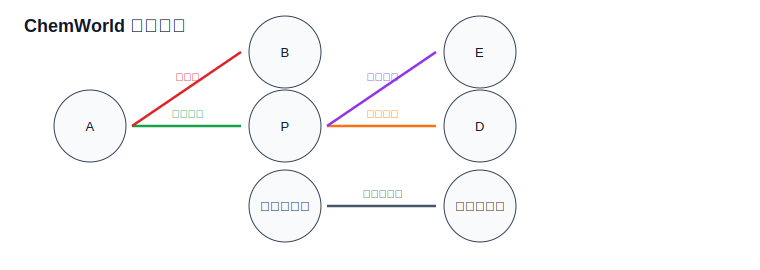

In [2]:
tu.display_tutorial_header(
    day=4,
    title='机制扫描与化工直觉',
    subtitle='用单因素扫描观察温度、时间、催化剂、溶剂和风险之间的 trade-off。',
    focus=[
        '温度扫描',
        '时间扫描',
        '催化剂-溶剂交互',
        '风险-得分权衡',
    ],
    deliverables=[
        '一张温度扫描图',
        '一张交互热图',
        '一个机制假设',
    ],
    project_link='机制扫描帮助你避免把 leaderboard 当成盲目刷分游戏。',
)
tu.display_course_map(4)
display(tu.reaction_network_svg())


In [3]:
tu.display_api_card()

## 第 4 天检查点

完成本 notebook 后，请确认你已经留下这些证据：

- 一张来自自己实验的轨迹表或 JSONL 文件
- 一张由自己实验数据生成的图
- 一个有化工意义的机制假设
- 一个下一轮实验建议
- 一条关于 GPT 或其他助手使用方式的记录


,temperature_C,yield,conversion,degradation,risk,score
0,30.0,0.8432,0.9288,0.0119,0.1019,0.6613
1,60.0,0.8804,0.9980,0.0273,0.1042,0.6797
2,90.0,0.7980,1.0000,0.0999,0.1154,0.6138
3,120.0,0.5973,1.0000,0.2881,0.1820,0.4466
4,150.0,0.2888,1.0000,0.5891,0.3370,0.1765


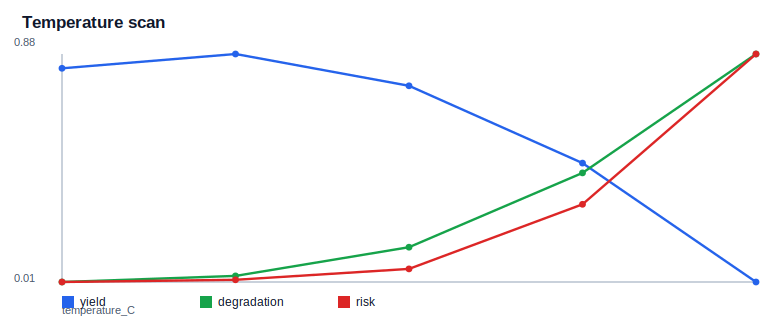

In [5]:
base_recipe = {
    "temperature": 90.0,
    "time": 0.50,
    "initial_concentration": 0.40,
    "stirring_speed": 720.0,
    "catalyst": 1,
    "solvent": 2,
}
temp_rows = []
for temp_c in [30.0, 60.0, 90.0, 120.0, 150.0]:
    recipe = dict(base_recipe, temperature=temp_c)
    temp_rows.append(tu.run_recipe(recipe, seed=31))
temp_df = pd.DataFrame(temp_rows)
display(temp_df[["temperature_C", "yield", "conversion", "degradation", "risk", "score"]])
display(
    tu.line_svg(
        temp_df,
        x="temperature_C",
        ys=["yield", "degradation", "risk"],
        title="Temperature scan",
    )
)

,time_h,yield,conversion,degradation,risk,score
0,0.25,0.8465,1.0,0.0489,0.1154,0.6519
1,0.50,0.7980,1.0,0.0999,0.1154,0.6138
2,1.00,0.7049,1.0,0.1931,0.1154,0.5417
3,2.00,0.5499,1.0,0.3481,0.1154,0.4209
4,4.00,0.3343,1.0,0.5637,0.1154,0.2502
5,8.00,0.3343,1.0,0.5637,0.1154,0.2502


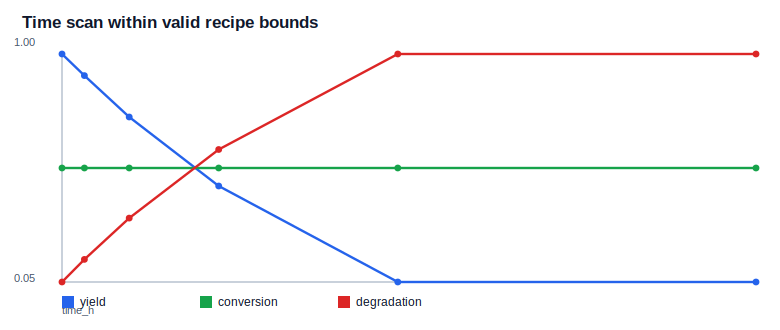

In [6]:
time_rows = []
for time_h in [0.25, 0.50, 1.00, 2.00, 4.00, 8.00]:
    recipe = dict(base_recipe, temperature=90.0, time=time_h)
    time_rows.append(tu.run_recipe(recipe, seed=31))
time_df = pd.DataFrame(time_rows)
display(time_df[["time_h", "yield", "conversion", "degradation", "risk", "score"]])
display(
    tu.line_svg(
        time_df,
        x="time_h",
        ys=["yield", "conversion", "degradation"],
        title="Time scan within valid recipe bounds",
    )
)

In [7]:
early = time_df.head(3)[["yield", "conversion", "degradation", "score"]]
assert early.drop_duplicates().shape[0] == early.shape[0]
display(pd.DataFrame({"time_scan_distinct_first_three": [True]}))

,time_scan_distinct_first_three
0,True


solvent,acetonitrile,ethanol,toluene,water
catalyst,,,,
cat_a,0.6057,0.5519,0.4963,0.6594
cat_b,0.6138,0.5805,0.5496,0.6758
cat_c,0.5471,0.4769,0.4233,0.6097
cat_d,0.6267,0.5924,0.5554,0.6794


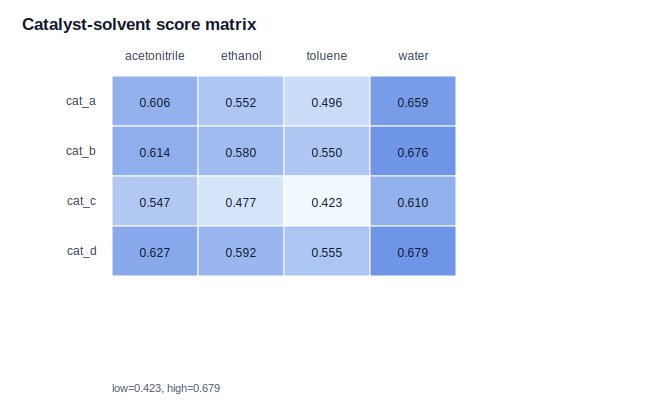

In [8]:
interaction_rows = []
for catalyst in range(len(tu.CATALYSTS)):
    for solvent in range(len(tu.SOLVENTS)):
        recipe = dict(base_recipe, catalyst=catalyst, solvent=solvent)
        interaction_rows.append(tu.run_recipe(recipe, seed=31))
interaction_df = pd.DataFrame(interaction_rows)
score_matrix = interaction_df.pivot(
    index="catalyst",
    columns="solvent",
    values="score",
)
display(score_matrix)
display(tu.heatmap_svg(score_matrix, title="Catalyst-solvent score matrix"))

,initial_concentration_M,yield,conversion,risk,score
0,0.15,0.7093,1.0,0.0973,0.5523
1,0.30,0.7066,1.0,0.1062,0.5464
2,0.60,0.7014,1.0,0.1444,0.5295
3,1.00,0.6944,1.0,0.2285,0.4988
4,1.60,0.6843,1.0,0.2826,0.4709


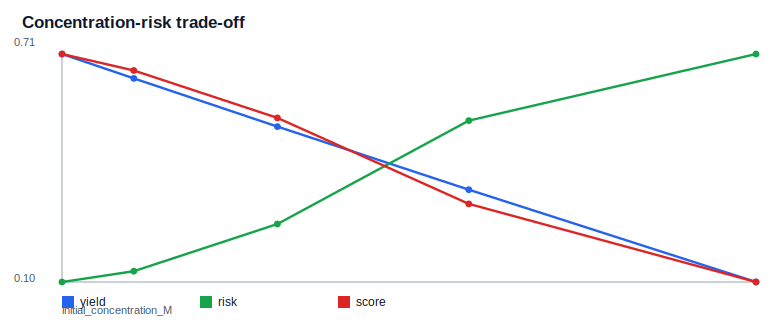

In [9]:
risk_rows = []
for concentration in [0.15, 0.30, 0.60, 1.00, 1.60]:
    recipe = dict(base_recipe, initial_concentration=concentration, time=1.0)
    risk_rows.append(tu.run_recipe(recipe, seed=31))
risk_df = pd.DataFrame(risk_rows)
display(risk_df[["initial_concentration_M", "yield", "conversion", "risk", "score"]])
display(
    tu.line_svg(
        risk_df,
        x="initial_concentration_M",
        ys=["yield", "risk", "score"],
        title="Concentration-risk trade-off",
    )
)

## 当天练习

根据三张图写出两个假设：

- 一个关于“如何提高产率”的假设；
- 一个关于“如何降低风险或降解”的假设。

明天我们会用 surrogate model 把这些假设变成候选实验。


## 课后反思

请用两三句话回答下面的问题，并把答案写进当天的实验日志。


In [10]:
tu.display_reflection_box(
    [
        '哪一个扫描最清楚地显示了非单调规律？',
        '你的下一轮实验会验证哪一个机制假设？',
    ]
)
